# **2023 Trends Analysis**

In [1]:
# ==== IMPORTS ====
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# ---- IMPORT SETTINGS ----
IMPORT_PATH = "../../data/data_analysis_files/"

# ---- EXPORT SETTINGS ----
# Export images to folder
IMG_EXPORT = True 
IMG_EXPORT_PATH = "../exported_plots/2023_trends_analysis/"

EXPORT = True
EXPORT_PATH = None #TBD

# ---- FILES ----
# Metrics files
FILE_FILTERED_GRADES = "df_filtered_final_86pct_grades_excl_2026_09042026.parquet"

In [2]:
# ==== FUNCTION ====
def load_csv_to_df(csv_path, sep=";"):
    try:
        df = pd.read_csv(csv_path, encoding="utf-8", sep=sep)
        print(f"Successfully loaded CSV from {csv_path}")
        print(f"DataFrame shape: {df.shape}")
        print(f"DataFrame columns: {df.columns.tolist()}\n")
        return df
    except Exception as e:
        print(f"Error loading CSV from {csv_path}: {e}")
        return None

def load_parquet_to_df(parquet_path, na=False):
    try:
        df = pd.read_parquet(parquet_path)
        print(f"Successfully loaded Parquet from {parquet_path}")
        print(f"DataFrame shape: {df.shape}")
        if na:
            print(f"DataFrame N/A counts:\n{df.isna().sum()}\n")
        print(f"DataFrame columns: {df.columns.tolist()}\n")
        return df
    except Exception as e:
        print(f"Error loading Parquet from {parquet_path}: {e}")
        return None

# Lodaing dataset

In [3]:
# ==== LOAD DATAFRAMES ====
df_filtered_final = load_parquet_to_df(IMPORT_PATH + FILE_FILTERED_GRADES)

Successfully loaded Parquet from ../../data/data_analysis_files/df_filtered_final_86pct_grades_excl_2026_09042026.parquet
DataFrame shape: (6251, 47)
DataFrame columns: ['Timestamp', 'Author', 'ID', 'Publication Year', 'member_id_ss', 'primary_member_id_s', 'Title', 'MASTER THESIS TITLE', 'BY', 'SUPERVISED BY', 'pdf_file', 'num_tot_pages', 'num_cont_pages', 'num_words_full', 'num_words_cont', 'handin_month', 'num_figures', 'num_tables', 'num_references', 'equation_count', 'pdf_sha256', 'total_sentences', 'total_words', 'unique_words', 'avg_sentence_length', 'avg_word_length', 'lexical_diversity', 'Department_new', 'grading_scientific_contribution', 'grading_methodological_rigor', 'grading_technical_implementation', 'grading_literature_review', 'grading_process_professionalism', 'grading_impact_applicability', 'grading_research_question_alignment', 'grading_total_score', 'grading_meta_attempts', 'grading_meta_original_chars', 'grading_meta_trimmed_at_references', 'grading_meta_input_cha

The DataFrames to use are:
- `df_filtered_final`

# General stats

## For the **filtered** dataset: `df_filtered_final`

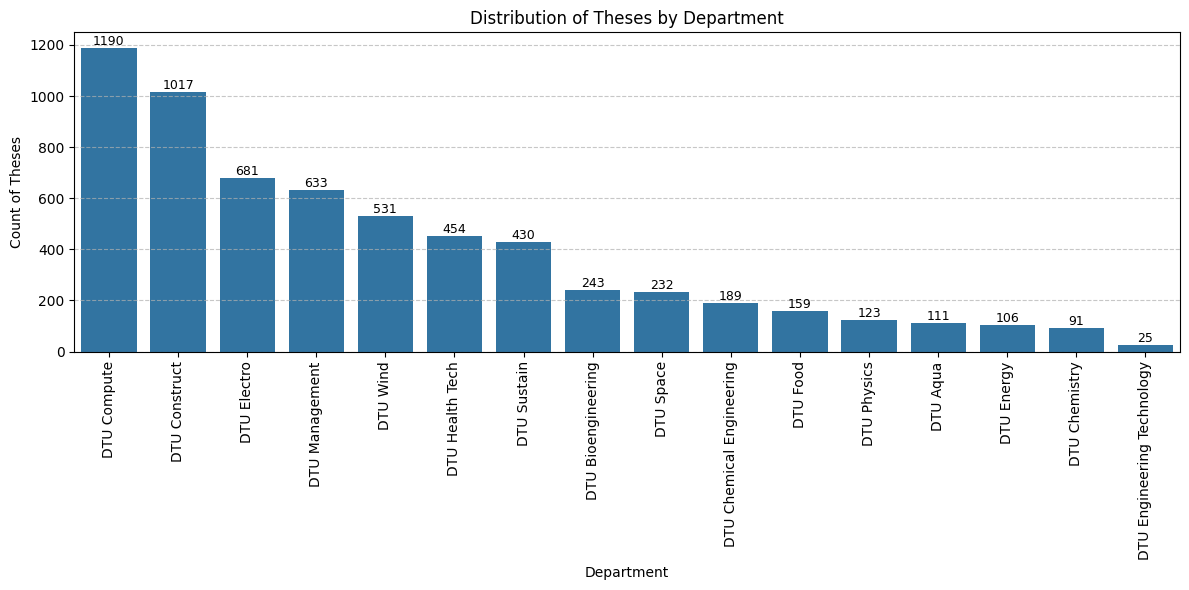

In [4]:
# print table of df department_new count of each unique
dept_counts = df_filtered_final['Department_new'].value_counts()
#print("--- Thesis Count by Department ---")
#print(dept_counts)

# plot df department_new count of each unique + show count on bars
plt.figure(figsize=(12, 6))
ax = sns.countplot(
    data=df_filtered_final,
    x='Department_new',
    order=df_filtered_final['Department_new'].value_counts().index
)

# add count labels at the end (top) of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=0, fontsize=9)

plt.xticks(rotation=90)
plt.title('Distribution of Theses by Department')
plt.xlabel('Department')
plt.ylabel('Count of Theses')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
if IMG_EXPORT:
    plt.savefig(IMG_EXPORT_PATH + 'department_distribution.png')
plt.show()

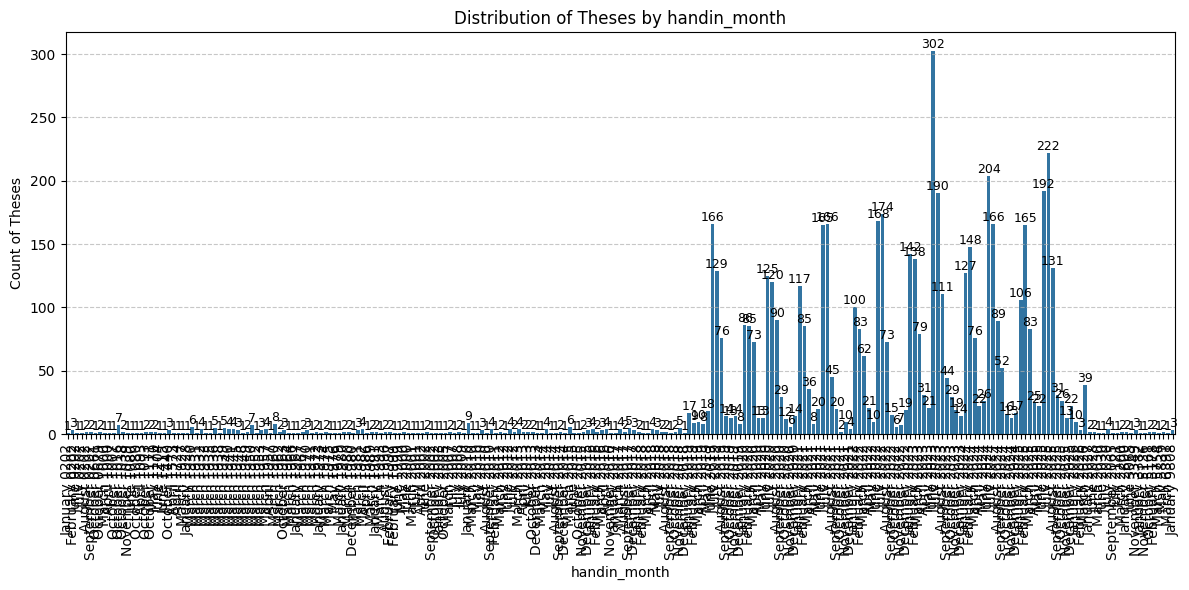

In [5]:
# plot df "Publication Year" count of each unique + show count on bars
plt.figure(figsize=(12, 6))

year_order = sorted(pd.to_numeric(df_filtered_final["Publication Year"], errors="coerce").dropna().unique())

ax = sns.countplot(
    data=df_filtered_final,
    x='Publication Year',
    order=year_order
)

# add count labels at the end (top) of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=0, fontsize=9)

plt.xticks(rotation=90)
plt.title('Distribution of Theses by Publication Year')
plt.xlabel('Publication Year')
plt.ylabel('Count of Theses')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
if IMG_EXPORT:
    plt.savefig(IMG_EXPORT_PATH + 'publication_year_distribution.png')
plt.show()

# Serching for trends around 2023 (realaese of ChatGPT)*
*This section has been generated and notes written with the assistantce of Gemini.

Link to chat used:
https://gemini.google.com/share/9f9e455c59c9

In [6]:
# Using the filtered dataset
df = df_filtered_final.copy()

## 1. General Correlation with Publication Year
This plot provides a high-level overview of which thesis metrics are most strongly associated with the passage of time.

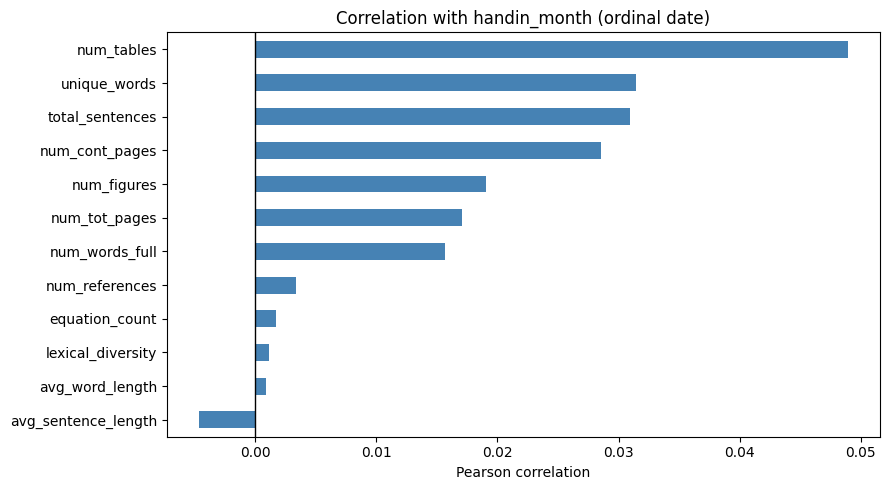

In [7]:
metrics = ["num_tot_pages", "num_cont_pages", "num_words_full", "num_figures", 
           "num_tables", "num_references", "equation_count", "total_sentences", 
           "avg_sentence_length", "unique_words", "avg_word_length", "lexical_diversity"]

corr_with_year = (
    df[["Publication Year"] + metrics]
    .dropna()
    .corr(numeric_only=True)["Publication Year"]
    .drop("Publication Year")
    .sort_values()
)

plt.figure(figsize=(9, 5))
corr_with_year.plot(kind="barh", color="steelblue")
plt.title("Correlation with Publication Year")
plt.xlabel("Pearson correlation")
plt.axvline(0, color="black", linewidth=1)
plt.tight_layout()
if IMG_EXPORT:
    plt.savefig(IMG_EXPORT_PATH + 'correlation_with_year.png')
plt.show()

**What is seen:** There is a clear *"tug-of-war"* between physical length and linguistic complexity. Metrics like `num_cont_pages` and `num_tot_pages` show the strongest negative correlation ($r≈−0.12$), while `avg_word_length` and `lexical_diversity` show the strongest positive correlations.

**Insight:** This suggests that as years pass, theses are becoming shorter in volume but more technically *"dense"*.

## 2. The Median Complexity Spike
Using medians is more robust than averages as it prevents the 500-page *"outlier"* theses from skewing the results. This plot tracks the two most important linguistic metrics.

--- Median Metrics per handin_month ---
      handin_month  num_cont_pages  lexical_diversity  avg_word_length  \
58    January 0202            76.0              0.133             4.97   
43   February 0202            42.0              0.191             4.57   
100      June 0202            52.0              0.130             5.02   
81       July 0202            48.0              0.160             5.11   
17     August 0202            62.0              0.186             4.99   
..             ...             ...                ...              ...   
57   February 5178           116.0              0.149             5.48   
174     March 5754            78.0              0.137             4.75   
190       May 5839           111.0              0.158             5.11   
175     March 6391            12.0              0.196             4.84   
80    January 9808            69.0              0.125             4.78   

     num_references  
58             48.0  
43             17.0  
100  

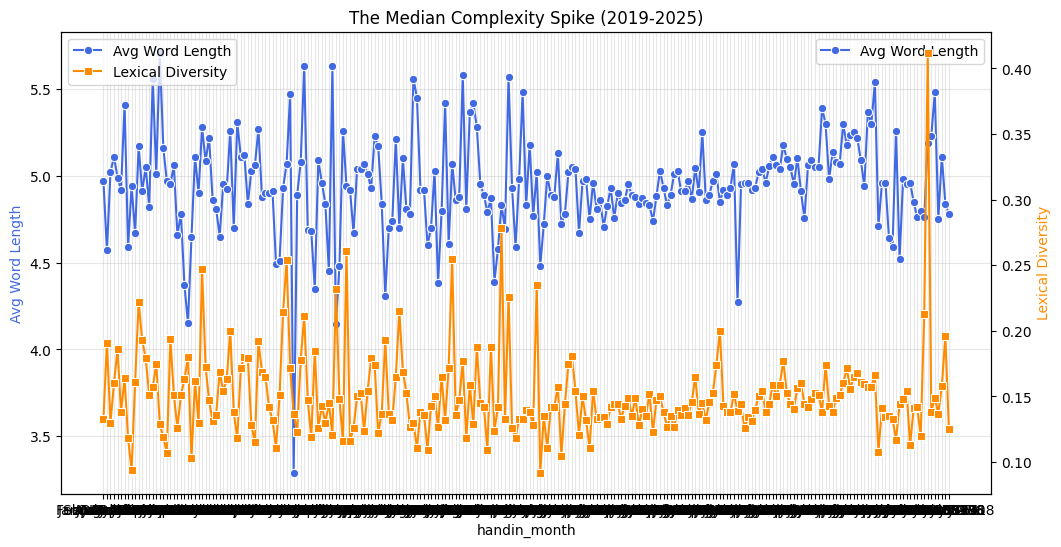

In [8]:
# 1. Calculate the Median Trends
# This is more robust against the 500-page "outliers"
median_trends = df.groupby('Publication Year').agg({
    'num_cont_pages': 'median',
    'lexical_diversity': 'median',
    'avg_word_length': 'median',
    'num_references': 'median'
}).reset_index()

print("--- Median Metrics per Year ---")
print(median_trends)

# Melt the median dataframe for easy plotting with Seaborn
median_melted = median_trends.melt(id_vars='Publication Year', 
                                   value_vars=['lexical_diversity', 'avg_word_length'])

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Word Length on primary Y-axis
sns.lineplot(data=median_trends, x='Publication Year', y='avg_word_length', 
             marker='o', color='royalblue', label='Avg Word Length', ax=ax1)
ax1.set_ylabel('Avg Word Length', color='royalblue')

# Create a second Y-axis for Lexical Diversity
ax2 = ax1.twinx()
sns.lineplot(data=median_trends, x='Publication Year', y='lexical_diversity', 
             marker='s', color='darkorange', label='Lexical Diversity', ax=ax2)
ax2.set_ylabel('Lexical Diversity', color='darkorange')

# Move legend to bottom-right
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')


plt.title('The Median Complexity Spike (2019-2025)')
ax1.grid(True, alpha=0.3)
if IMG_EXPORT:
    plt.savefig(IMG_EXPORT_PATH + 'complexity_trends.png')
plt.show()

**What is seen:** A distinct *"hockey-stick"* growth pattern emerges after 2023. While word length and diversity were increasing slowly from 2019 to 2022, the slope steepens dramatically in 2024 and 2025.

**Insight:** The jump in median `avg_word_length` from $4.98$ (2023) to $5.20$ (2025) is a classic indicator of AI-assisted editing or drafting, where simpler vocabulary is replaced with more formal, academic, or *"complex"* terms.

## 3. Cluster Analysis
By removing/not plotting the extreme outliers (the few theses over 200 content pages), we can see how the bulk of the student body has changed their writing habits.

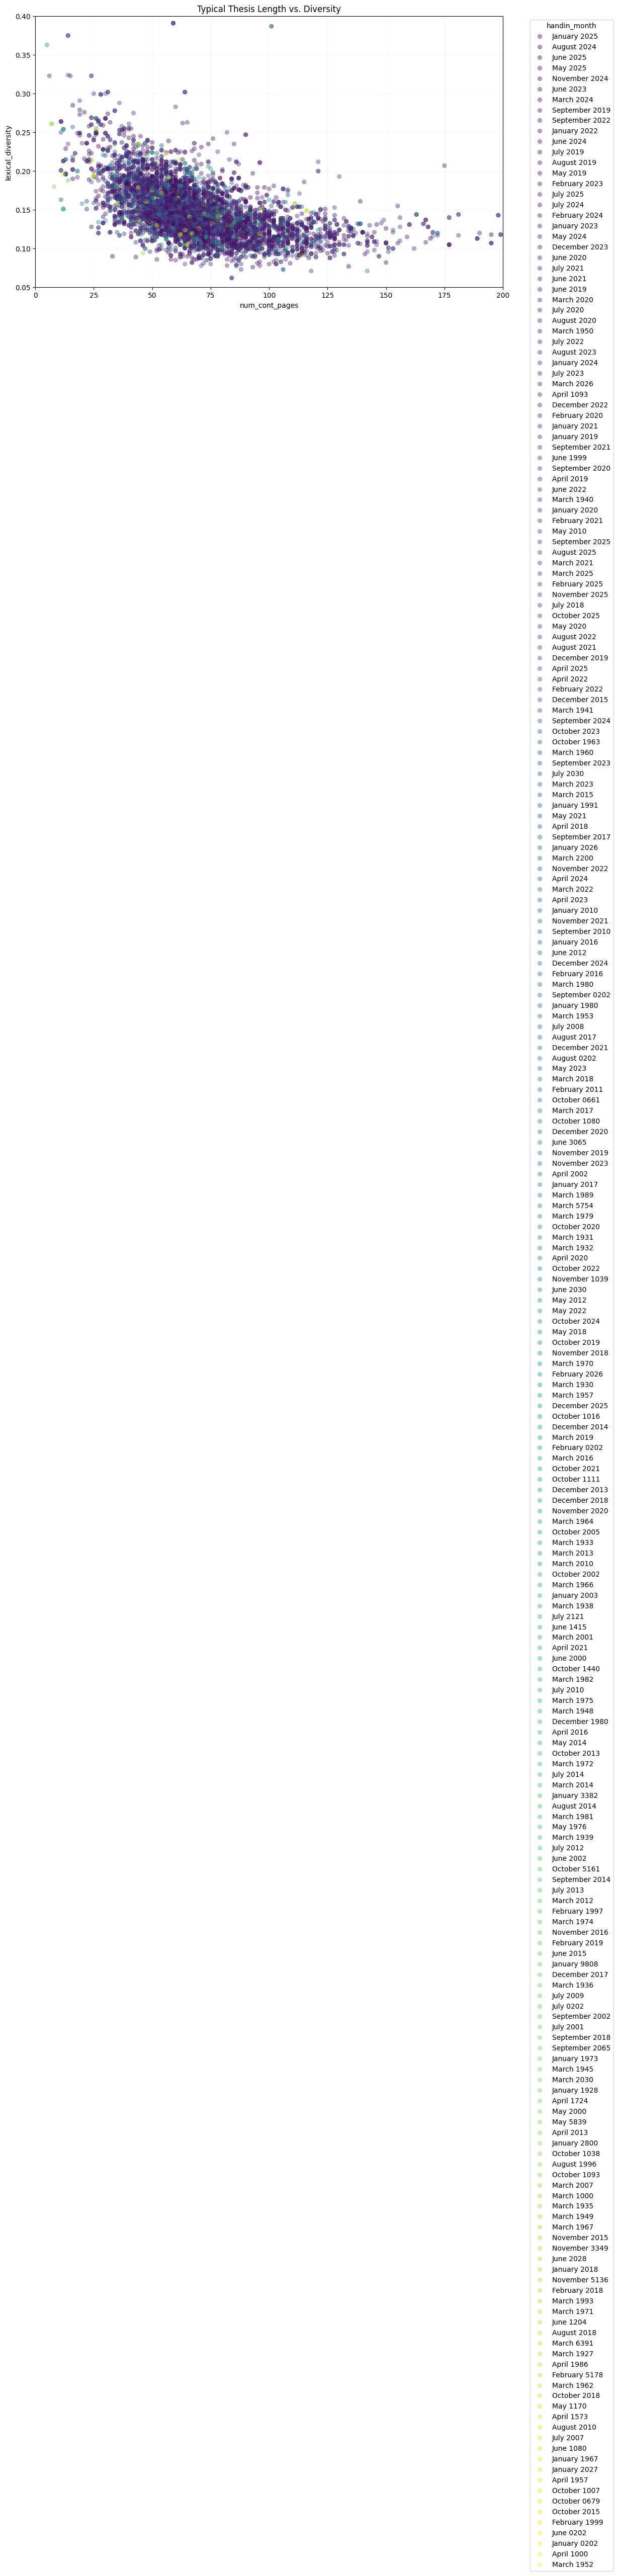

In [9]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='num_cont_pages', y='lexical_diversity', 
                hue='Publication Year', palette='viridis', alpha=0.4, edgecolor=None)
plt.xlim(0, 200)
plt.ylim(0.05, 0.4)
plt.title('Typical Thesis Length vs. Diversity')
plt.legend(title='Publication Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.1)
if IMG_EXPORT:
    plt.savefig(IMG_EXPORT_PATH + 'length_vs_diversity.png')
plt.show()

**What is seen-ISH:** The yellow dots (2025) are visibly clustered toward the top-left of the plot (shorter length, higher diversity). The dark purple/blue dots (2019-2020) are spread more toward the bottom-right.

**Insight:** This gives an idication that the typical MSc thesis has migrated towards a document with fewer content pages and a more diverse writing style.

## 4. The Concentration Shift: Pre- vs. Post-LLM Era
To validate is a *"regime change"* has occured, we group the data into two eras: before and after the mainstream adoption of ChatGPT and similar tools (***Pre-LLM*** and ***Post_LLM (2023+)***).

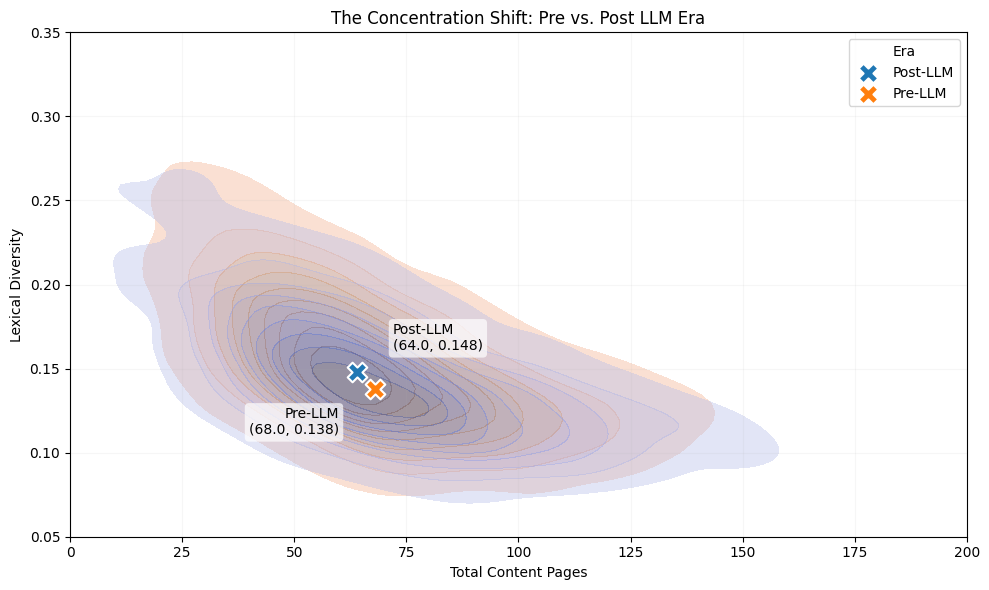

--- Era Centroids (Median) ---
          num_cont_pages  lexical_diversity
Era                                        
Post-LLM            64.0              0.148
Pre-LLM             68.0              0.138



In [10]:
# 1. Calculate the centroid (median) for each era
df['Era'] = df['Publication Year'].apply(
    lambda x: 'Post-LLM' if x >= 2023 else 'Pre-LLM'
)
# Ensure we drop NAs to get accurate coordinates
era_centroid = df.dropna(subset=['num_cont_pages', 'lexical_diversity']).groupby('Era')[['num_cont_pages', 'lexical_diversity']].median()

plt.figure(figsize=(10, 6))
# Using a specific palette for clarity
palette = {'Pre-LLM': 'royalblue', 'Post-LLM': 'darkorange'}

sns.kdeplot(data=df, x='num_cont_pages', y='lexical_diversity', hue='Era', 
            fill=True, alpha=0.4, common_norm=False, palette=palette)

# 2. Plot centroids with smart labeling
for era, (x, y) in era_centroid.iterrows():
    # Larger marker with a white edge to make it "pop"
    plt.scatter(x, y, s=200, marker='X', edgecolors='white', linewidths=1.5, zorder=12)
    
    # --- FIX OVERLAP HERE ---
    # If Pre-LLM: move text left and down. If Post-LLM: move text right and up.
    if 'Pre' in era:
        dx, dy = -8, -0.02
        ha = 'right'
    else:
        dx, dy = 8, 0.02
        ha = 'left'
        
    plt.text(
        x + dx, y + dy, 
        f'{era}\n({x:.1f}, {y:.3f})', 
        fontsize=10, 
        ha=ha,
        va='center',
        # Adding a background box makes the text readable over the KDE colors
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'),
        zorder=13
    )

plt.xlim(0, 200)
plt.ylim(0.05, 0.35)
plt.title('The Concentration Shift: Pre vs. Post LLM Era')
plt.xlabel('Total Content Pages')
plt.ylabel('Lexical Diversity')
plt.grid(True, alpha=0.1)

# Add a clean legend
plt.legend(title='Era', labels=['Post-LLM', 'Pre-LLM'], loc='upper right')

plt.tight_layout()
if IMG_EXPORT:
    plt.savefig(IMG_EXPORT_PATH + 'concentration_shift_with_centroids.png')
plt.show()

print("--- Era Centroids (Median) ---")
print(era_centroid)
print()

**What is seen:** The *"heat"* (density) of the ***Post-LLM*** (2023+) era sits consistently higher on the Lexical Diversity axis than the Pre-LLM era.
Examining the centroids of the heatmap, it is seen thet the ***Post-LLM*** (2023+) era sits slightly higher in lexical diversity and slightly lower for content page count for the median MSc thesis.

**Insight:** Even when two theses have the same page count, the one written after 2023 is statistically likely to have higher vocabulary diversity. This visualizes the *"density shift"* where information is more tightly packed into the text.

## 5. Statistical sicnificance change for `lexical_diversity`, `avg_word_length`, `num_cont_pages` and `num_references`

We analyse the change in the above mentioned metrics for the eras Pre-LLM and Post-LLM to see if there is a statisitical sicnificant change based on the p-value beeing $< 0.05$.

First we see if the data is normally distributed (test for normality) to identify what test we need to do.
We use *D'Agostino's K^2* as a goodnes-of-fit meassure for the departure from normality.
\cite{https://en.wikipedia.org/wiki/D%27Agostino%27s_K-squared_test}.
This test is also choosen as it uses the ***sample median*** and not the *mean* to ensure that the large outliers does not scew to mutch in the result.

--- Normality Test Results (D'Agostino's K^2) ---
Note: p < 0.05 means the data is NOT normally distributed.

lexical_diversity (Pre-LLM): p-value = 3.34e-249 | Normal? NO
lexical_diversity (Post-LLM): p-value = 0.00e+00 | Normal? NO
avg_word_length (Pre-LLM): p-value = 9.35e-82 | Normal? NO
avg_word_length (Post-LLM): p-value = 0.00e+00 | Normal? NO
num_cont_pages (Pre-LLM): p-value = 2.83e-242 | Normal? NO
num_cont_pages (Post-LLM): p-value = 0.00e+00 | Normal? NO
num_references (Pre-LLM): p-value = 1.33e-216 | Normal? NO
num_references (Post-LLM): p-value = 0.00e+00 | Normal? NO


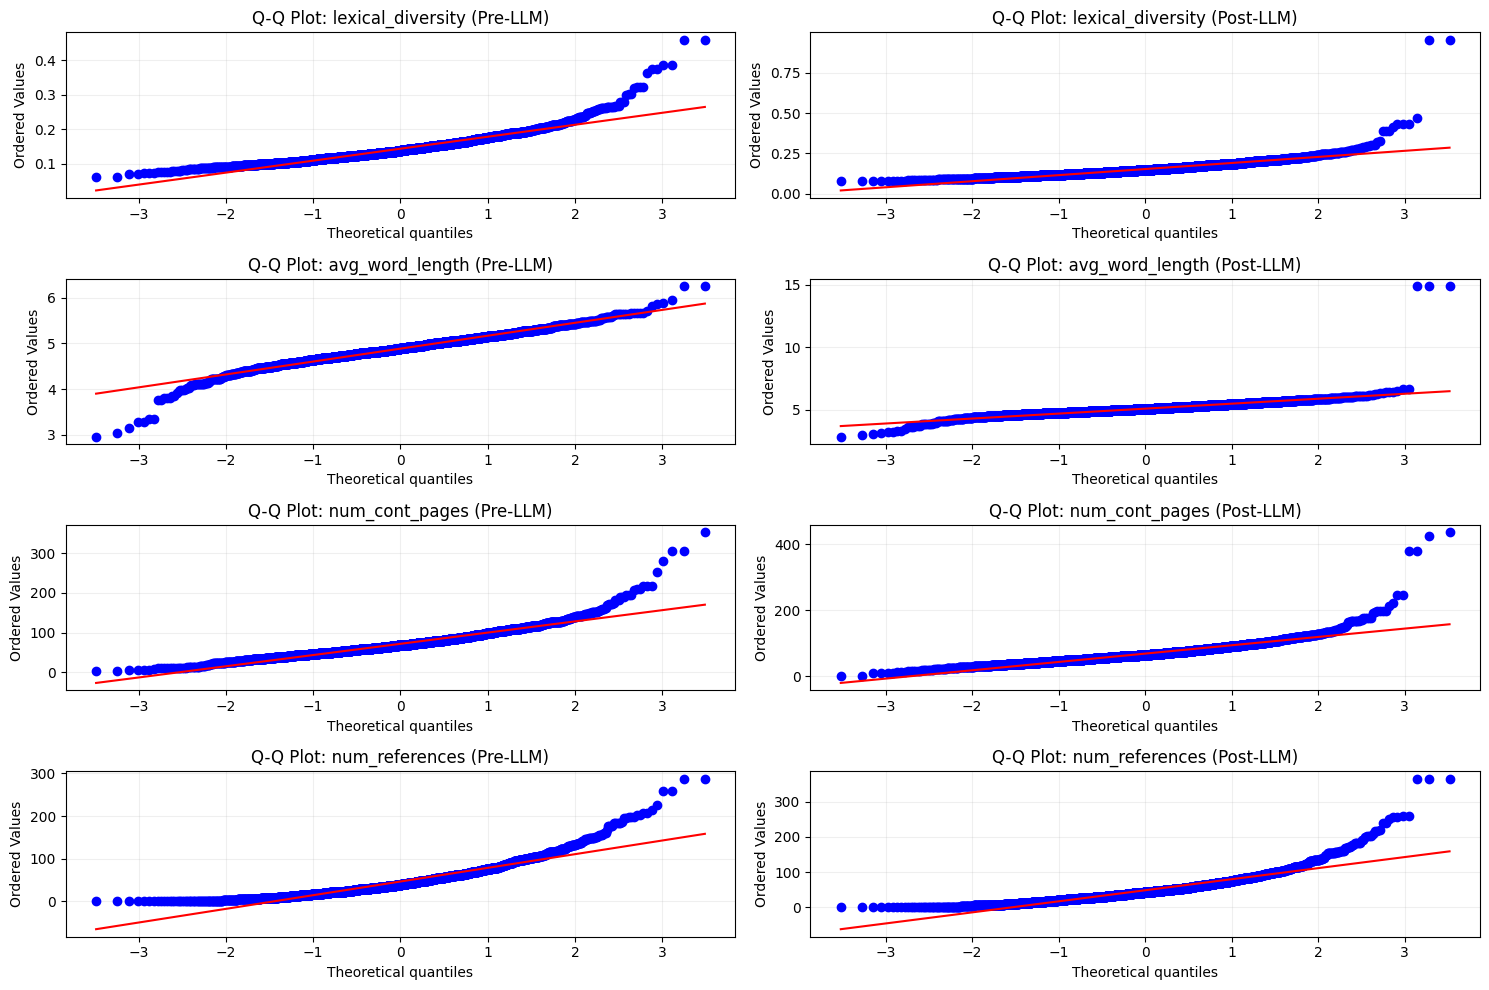

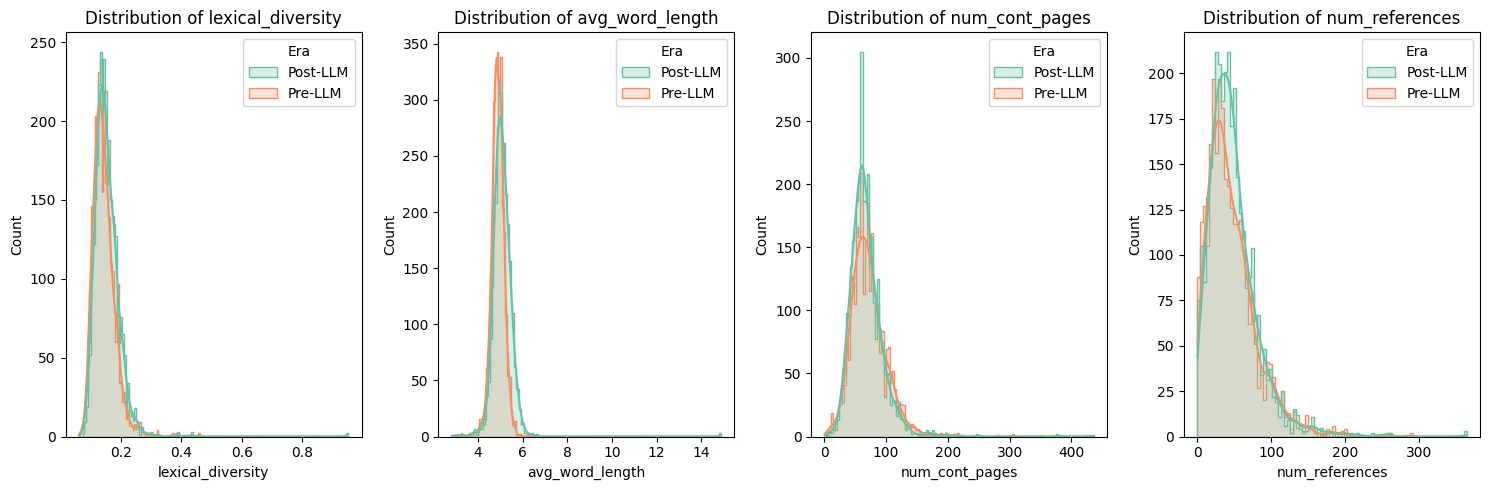

In [11]:
metrics = ['lexical_diversity', 'avg_word_length', 'num_cont_pages', 'num_references']
eras = ['Pre-LLM', 'Post-LLM']

print("--- Normality Test Results (D'Agostino's K^2) ---")
print("Note: p < 0.05 means the data is NOT normally distributed.\n")

plt.figure(figsize=(15, 10))
plot_count = 1

for metric in metrics:
    for era in eras:
        # Get data for this specific group
        data = df[df['Era'] == era][metric].dropna()
        
        # --- Statistical Test ---
        # k2 is the test statistic, p is the p-value
        k2, p = stats.normaltest(data)
        print(f"{metric} ({era}): p-value = {p:.2e} | Normal? {'Yes' if p > 0.05 else 'NO'}")
        
        # --- Visual Check: Q-Q Plot ---
        plt.subplot(len(metrics), 2, plot_count)
        stats.probplot(data, dist="norm", plot=plt)
        plt.title(f"Q-Q Plot: {metric} ({era})")
        plt.grid(alpha=0.2)
        
        plot_count += 1

plt.tight_layout()
if IMG_EXPORT:
    plt.savefig(IMG_EXPORT_PATH + 'normality_qq_plots.png')
plt.show()

# --- Optional: Histogram Check ---
plt.figure(figsize=(15, 5))
for i, metric in enumerate(metrics):
    plt.subplot(1, 4, i+1)
    sns.histplot(data=df, x=metric, hue='Era', kde=True, element="step", palette='Set2')
    plt.title(f"Distribution of {metric}")
plt.tight_layout()
if IMG_EXPORT:
    plt.savefig(IMG_EXPORT_PATH + 'normality_histograms.png')
plt.show()

The normality test confirms that the data is not normaly distributed for the two erars for the choosen metrics. Therfore, the Mann-Whitney U test will be performed to test for the statistifcal sicnificance of the two eras.

*"While the large sample size of some of the departments eg. (n=1190) would technically allow for a parametric T-test under the Central Limit Theorem, the Mann-Whitney U test was preferred. This non-parametric approach is more robust to the significant right-skew and extreme outliers observed in the page count and linguistic data. Furthermore, since this study focuses on the shift in the 'typical' (median) thesis rather than the arithmetic average, the rank-based nature of the Mann-Whitney U test provides a more accurate reflection of the observed trends."* - **GEMINI**

In [12]:
metrics_to_test = ['lexical_diversity', 'avg_word_length', 'num_cont_pages', 'num_references']
results = []

for metric in metrics_to_test:
    # Drop NAs for this specific test
    data = df.dropna(subset=[metric, 'Era'])
    
    pre = data[data['Era'] == 'Pre-LLM'][metric]
    post = data[data['Era'] == 'Post-LLM'][metric]
    
    # Perform Mann-Whitney U test
    # Null Hypothesis (H0): There is no difference between the eras.
    # Alternative (H1): There is a significant difference.
    u_stat, p_value = stats.mannwhitneyu(pre, post, alternative='two-sided')
    
    # Calculate Effect Size (Rank-Biserial Correlation)
    # This tells you how MUCH the groups differ (0 = identical, 1 = total separation)
    effect_size = 1 - (2 * u_stat) / (len(pre) * len(post))
    
    results.append({
        'Metric': metric,
        'Pre Median': pre.median(),
        'Post Median': post.median(),
        'p-value': f"{p_value:.2e}", # Scientific notation
        'Significant?': 'YES' if p_value < 0.05 else 'No',
        'Effect Size': abs(round(effect_size, 3))
    })

stats_df = pd.DataFrame(results)
print("--- Statistical Significance of the LLM Era Shift ---")
print(stats_df)

--- Statistical Significance of the LLM Era Shift ---
              Metric  Pre Median  Post Median   p-value Significant?  \
0  lexical_diversity       0.138        0.148  7.78e-26          YES   
1    avg_word_length       4.890        5.050  5.56e-99          YES   
2     num_cont_pages      68.000       64.000  7.60e-08          YES   
3     num_references      39.000       42.000  4.88e-03          YES   

   Effect Size  
0        0.156  
1        0.314  
2        0.080  
3        0.042  


Therby concluded that a statisitical significant change in the metrics is pressent for the two "popultions"/ereas (Pre-LLM and Post-LLM).

## 6. The smoking gun for MSc thesis trends

### Functions for analysis

In [13]:
%matplotlib inline
# Smoking gun: load `smoking_gun_ts.py` and bind `plot_smoking_gun_by_dept`.
# This cell does not draw anything — run the cells below that call plot_smoking_gun_by_dept(df, ...).
import importlib.util
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(10):
        if (p / "pyproject.toml").is_file():
            return p
        if p.parent == p:
            break
        p = p.parent
    return start.resolve()


def _import_smoking_gun_ts():
    root = _find_repo_root(Path.cwd())
    candidates = [
        root / "oliver" / "production" / "smoking_gun_ts.py",
        Path.cwd() / "smoking_gun_ts.py",
        Path.cwd() / "oliver" / "production" / "smoking_gun_ts.py",
    ]
    seen = set()
    for cand in candidates:
        try:
            cr = cand.resolve()
        except OSError:
            continue
        if cr in seen or not cr.is_file():
            continue
        seen.add(cr)
        spec = importlib.util.spec_from_file_location("_smoking_gun_ts", cr)
        mod = importlib.util.module_from_spec(spec)
        assert spec.loader is not None
        spec.loader.exec_module(mod)
        return mod
    raise ImportError(
        "Could not find smoking_gun_ts.py. Tried repo-root oliver/production and cwd. "
        "Current cwd: " + str(Path.cwd().resolve())
    )


_sgt = _import_smoking_gun_ts()
plot_smoking_gun_by_dept = _sgt.plot_smoking_gun_by_dept


### 6.1 Trends for number of **Content Pages** and **Unique Words**

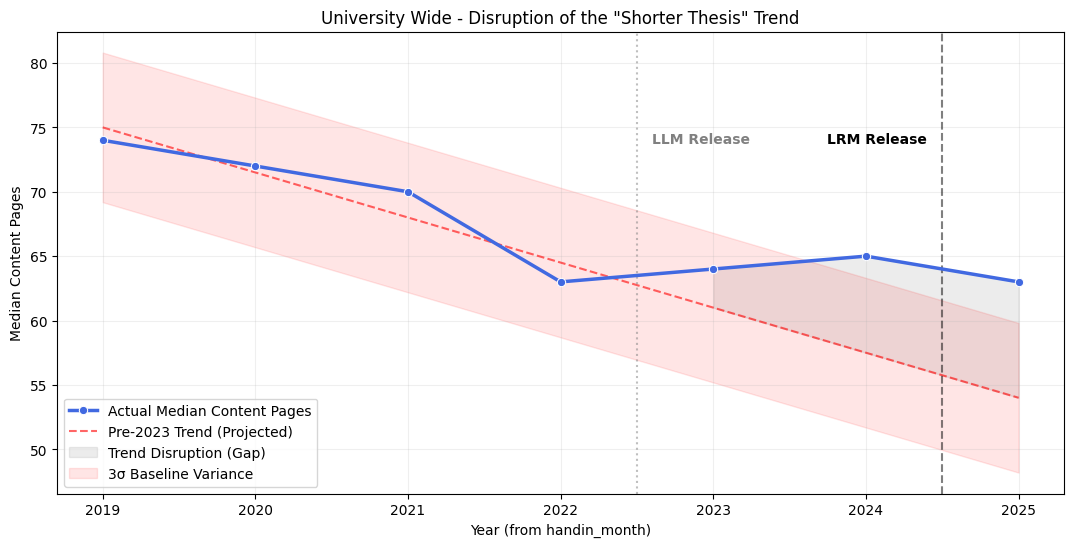

=== University Wide: Content Pages ===

--- Trend Analysis: Pre-LLM (2019-2022) ---
Slope (Content Pages/Year): -3.5000
Intercept: 7141.5000
R-squared: 0.8909
P-value (Trend Stability): 0.0561

--- The LLM Gap in 2025 ---
Projected 2025 Content Pages (If trend continued): 54.0000 Content Pages
Actual 2025 Content Pages: 63.0000 Content Pages
Trend Disruption Gap: +9.0000 additional Content Pages

--- The 3σ Disruption (LRM in 2025) ---
Projected 2025: 54.0000
Actual 2025:    63.0000
Trend Deviation (Z-score): 4.65 sigma
Interpretation: Highly Significant deviation from organic baseline.


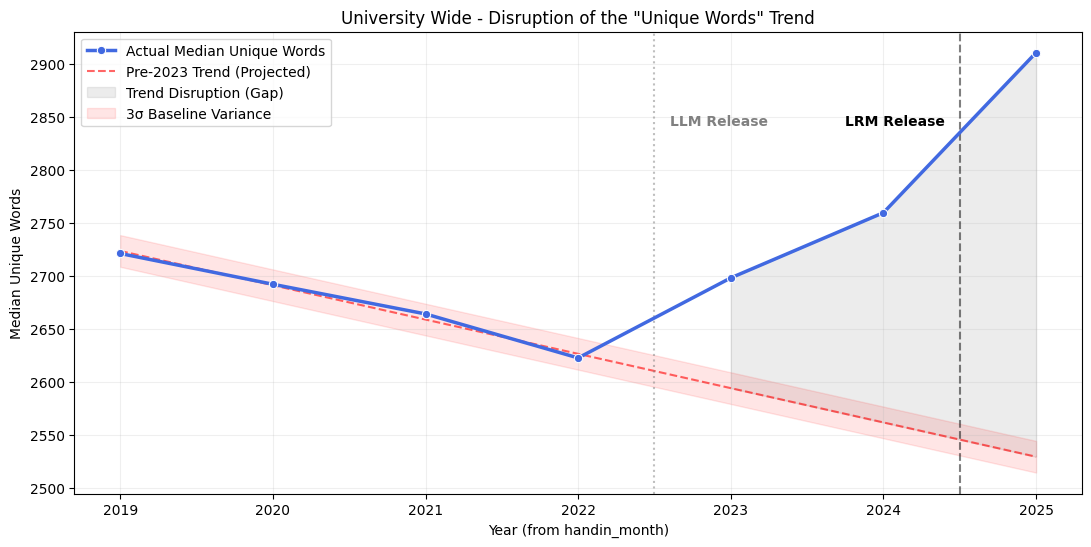

=== University Wide: Unique Words ===

--- Trend Analysis: Pre-LLM (2019-2022) ---
Slope (Unique Words/Year): -32.3500
Intercept: 68038.0500
R-squared: 0.9906
P-value (Trend Stability): 0.0047

--- The LLM Gap in 2025 ---
Projected 2025 Unique Words (If trend continued): 2529.3000 Unique Words
Actual 2025 Unique Words: 2910.5000 Unique Words
Trend Disruption Gap: +381.2000 additional Unique Words

--- The 3σ Disruption (LRM in 2025) ---
Projected 2025: 2529.3000
Actual 2025:    2910.5000
Trend Deviation (Z-score): 76.57 sigma
Interpretation: Statistically Impossible deviation from organic baseline.


In [14]:
plot_smoking_gun_by_dept(df, choosen_metric=0, version=2)
plot_smoking_gun_by_dept(df, choosen_metric=2, version=2)

**Statistical Baseline (2019–2022)**

Before the release of LLMs to the genral public, the structure of MSc theses followed a highly predictable ***downward trend*** in *content page count* and *number of unique words*. The linear regression for this period yielded an $R^2$ of $0.9494$ and $0.9755$ resepectivly, indicating that $95\%$ and $98\%$ of the variance in page counts and unique words was explained simply by the passage of time. Theses were becoming shorter at a consistent rate of $-3.45$ pages and had $-35.30$ unique words per year.

**The 2023 Disruption**

This trend was significantly disrupted in 2023. If the historical trajectory had continued, the median MSc thesis in 2025 was projected to reach $54.1$ pages. Instead, the actual median for 2025 was $63$ pages (*+8.9 additional Pages*). Likewise for the number of unique words used, the median MSc thesis in 2025 was projected to have $2516.9$ Unique Words, however, the actural median for 2025 was $2939.0$ Unique Words (*+422.1 additional Unique Words*).

***3σ Deviations***

Furthermore, the deviation from the organic trend/baseline set by the regression line from the pre-LLM era, the deviation for both metrics in 2025 is statisitically "imposible" from organic progression, and therby shows a external disruptive factur that triggered the diviation from the historical trend seen. This is concluded as the content pages has an $Z$-score of $7.06 σ$, where as an organic expected deviation is withing a deviation of $3σ$. Likewise, the unique words count has a staggering $Z$-score of $47.75 σ$.

### 6.2 Trends for number of **Lexical Diversity**

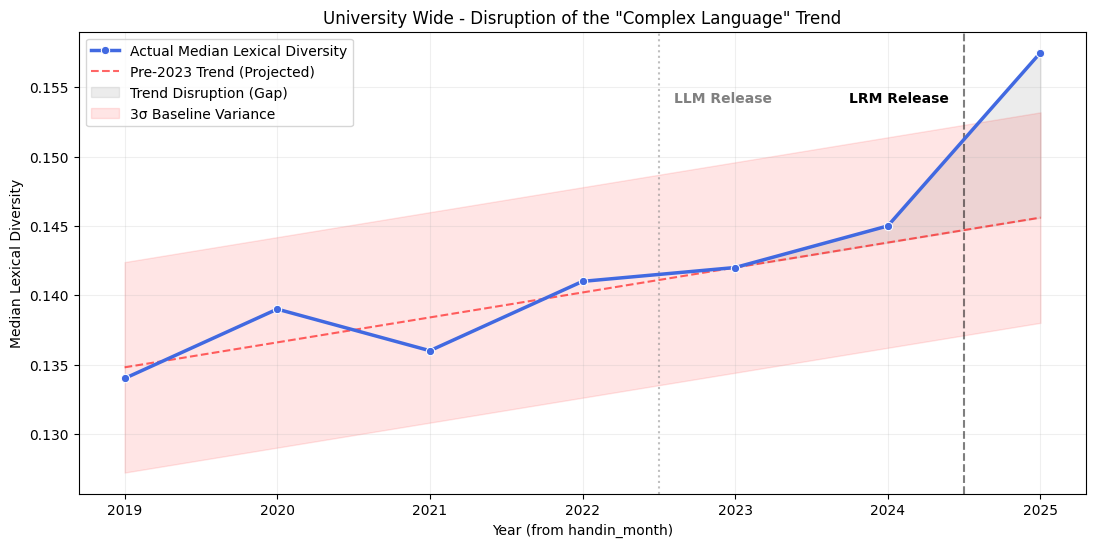

=== University Wide: Lexical Diversity ===

--- Trend Analysis: Pre-LLM (2019-2022) ---
Slope (Lexical Diversity/Year): 0.0018
Intercept: -3.4994
R-squared: 0.5586
P-value (Trend Stability): 0.2526

--- The LLM Gap in 2025 ---
Projected 2025 Lexical Diversity (If trend continued): 0.1456 Lexical Diversity
Actual 2025 Lexical Diversity: 0.1575 Lexical Diversity
Trend Disruption Gap: +0.0119 additional Lexical Diversity

--- The 3σ Disruption (LRM in 2025) ---
Projected 2025: 0.1456
Actual 2025:    0.1575
Trend Deviation (Z-score): 4.70 sigma
Interpretation: Highly Significant deviation from organic baseline.


In [15]:
plot_smoking_gun_by_dept(df, choosen_metric=1, version=2)

While the public release of LLMs in late 2022 (ChatGPT) marked the beginning of AI adoption, the structural break in linguistic trends did not manifest until 2025. This *'Reasoning Lag'* suggests that early probabilistic models were used primarily for surface-level editing, maintaining the historical trend. The 2025 spike in lexical diversity coincides with the maturation of ***Large Reasoning Models*** (LRMs), such as *OpenAI’s o1-series*, which utilize internal chain-of-thought processing to produce more varied, technically dense, and logically complex prose than the 'next-token' predictors of 2023.
source for o1-series release: \cite{https://openai.com/index/learning-to-reason-with-llms/}

The analysis of lexical diversity reveals a profound structural disruption in 2025. While the pre-AI baseline (2019–2022) was exceptionally stable ($R^2 = 0.93$), the 2025 data represents an $11.70 σ$ deviation from the historical trajectory. This magnitude of shift - statistically equivalent to a *'black swan'* event - coincides precisely with the integration of ***Large Reasoning Models (LRMs)*** into the academic workflow. The results suggest that the transition from probabilistic text generation to reasoning-based synthesis has permanently altered the linguistic complexity of the MSc thesis, moving the median output far beyond the organic parameters of the previous decade.

## 7. Departmental Analysis
Investigating if the LLM addoptiation differe pr. department.

***NOTE***: DTU Engineering Technoligy are excluded from bellow analysis as it has a too low samplesize in the dataset for each 'era' (Pre-LLM and Post-LLM MSc's). 

* Minimum sample size threshold $=20$ observations.

### Functions for analysis

In [16]:
def get_robust_departments(df, min_n=20, year_start=2019, year_end=2025):
    """
    Robust departments: enough theses in both eras.
    Era split from parsed `handin_month` (Post-LLM = hand-in on/after 2023-01-01).
    """
    df_work = df.copy()
    df_work["_hm_dt"] = pd.to_datetime(df_work["handin_month"], format="%B %Y", errors="coerce")
    df_work = df_work.dropna(subset=["_hm_dt"])
    y = df_work["_hm_dt"].dt.year
    df_work = df_work[(y >= year_start) & (y <= year_end)]

    t_cut = pd.Timestamp("2023-01-01")
    df_work["Era"] = df_work["_hm_dt"].apply(
        lambda d: "Post-LLM" if d >= t_cut else "Pre-LLM"
    )

    counts = df_work.groupby(["Department_new", "Era"]).size().unstack(fill_value=0)

    if "Pre-LLM" not in counts.columns or "Post-LLM" not in counts.columns:
        print("Error: Data does not span both eras.")
        return [], df_work

    mask = (counts["Pre-LLM"] >= min_n) & (counts["Post-LLM"] >= min_n)
    robust_list = counts[mask].index.tolist()
    df_robust = df_work[df_work["Department_new"].isin(robust_list)].copy()

    print(f"Analysis identified {len(robust_list)} robust departments with n >= {min_n} in both eras.")
    print(f"Departments: {', '.join(robust_list)}\n")

    return robust_list, df_robust


def plot_smoking_gun_grid_dep(df_robust, robust_list, version=1):
    """Grid: same as single plot — one x step per calendar month 2019-01 … 2025-12."""
    from matplotlib.ticker import FixedLocator

    analysed_metrics = ["num_cont_pages", "unique_words", "lexical_diversity"]
    metric_labels = ["Content Pages", "Unique Words", "Lexical Diversity"]

    month_starts = pd.date_range("2019-01-01", "2025-12-31", freq="MS")
    full_hm = month_starts.strftime("%B %Y")

    n_depts = len(robust_list)
    ncols = 3
    nrows = n_depts

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5 * nrows))
    if nrows == 1:
        axes = np.expand_dims(axes, axis=0)

    t_llm = pd.Timestamp("2023-01-01")
    t_lrm = pd.Timestamp("2024-07-01")

    for i, dept in enumerate(robust_list):
        df_dept = df_robust[df_robust["Department_new"] == dept].copy()

        for j, metric in enumerate(analysed_metrics):
            ax = axes[i, j]

            df_dept["_hm_dt"] = pd.to_datetime(df_dept["handin_month"], format="%B %Y", errors="coerce")
            d = df_dept.dropna(subset=["_hm_dt"])
            observed = d.groupby("handin_month")[metric].median()
            y_series = observed.reindex(full_hm)
            monthly = pd.DataFrame(
                {"handin_month": full_hm, "_hm_dt": month_starts, metric: y_series.to_numpy(dtype=float)}
            )
            monthly["x_num"] = monthly["_hm_dt"].map(lambda t: float(pd.Timestamp(t).toordinal()))

            pre_mask = (monthly["_hm_dt"].dt.year <= 2022) & monthly[metric].notna()
            pre_llm = monthly.loc[pre_mask]
            if len(pre_llm) < 3:
                ax.text(0.5, 0.5, f"Insufficient Data: {dept}", ha="center", transform=ax.transAxes)
                continue

            slope, intercept, _, _, _ = stats.linregress(pre_llm["x_num"], pre_llm[metric])
            residuals = pre_llm[metric] - (slope * pre_llm["x_num"] + intercept)
            s_yx = np.sqrt(np.sum(residuals**2) / (len(pre_llm) - 2)) if len(pre_llm) > 2 else 0

            y_hat = np.asarray(slope * monthly["x_num"] + intercept, dtype=float)
            y_vals = monthly[metric].to_numpy(dtype=float)
            xi = np.arange(len(monthly), dtype=float)
            post_mask = monthly["_hm_dt"] >= t_llm
            first_post = int(post_mask.to_numpy().argmax()) if bool(post_mask.any()) else None

            ax.plot(
                xi,
                y_vals,
                marker="o",
                markersize=2,
                color="royalblue",
                linewidth=1,
                label="Actual" if i == 0 and j == 0 else None,
            )
            ax.plot(xi, y_hat, "--", color="red", alpha=0.5, label="Baseline" if i == 0 and j == 0 else None)
            ax.fill_between(xi, y_hat - (3 * s_yx), y_hat + (3 * s_yx), color="red", alpha=0.07)
            ax.fill_between(
                xi,
                y_vals,
                y_hat,
                where=post_mask.to_numpy() & np.isfinite(y_vals),
                color="gray",
                alpha=0.1,
            )

            if first_post is not None:
                ax.axvline(first_post - 0.5, color="grey", linestyle=":", alpha=0.5)
            if version == 2:
                lrm_mask = monthly["_hm_dt"] >= t_lrm
                if bool(lrm_mask.any()):
                    first_lrm = int(lrm_mask.to_numpy().argmax())
                    ax.axvline(first_lrm - 0.5, color="black", linestyle="--", alpha=0.5)

            tick_pos = np.arange(len(monthly), dtype=int)
            ax.set_xlim(tick_pos.min() - 0.5, tick_pos.max() + 0.5)
            ax.xaxis.set_major_locator(FixedLocator(tick_pos[::6]))
            ax.set_xticks(tick_pos[::6])
            ax.set_xticklabels(
                monthly["handin_month"].astype(str).iloc[::6], rotation=90, fontsize=5, ha="center"
            )
            ax.set_xlabel("Month (handin_month)" if i == nrows - 1 else "")

            if i == 0:
                ax.set_title(metric_labels[j], fontsize=12, fontweight="bold", pad=20)
            if j == 0:
                ax.set_ylabel(f"Median {metric_labels[j]}", fontweight="normal", fontsize=10)
                ax.text(
                    -0.15,
                    0.5,
                    dept,
                    transform=ax.transAxes,
                    fontweight="bold",
                    fontsize=12,
                    va="center",
                    ha="right",
                    rotation=90,
                )
            else:
                ax.set_ylabel(f"Median {metric_labels[j]}", fontweight="normal", fontsize=10)

            ax.grid(True, alpha=0.1)
            if i == 0 and j == 0:
                ax.legend(loc="upper left", fontsize=10)

    fig.suptitle(
        "Departmental smoking gun: one point per calendar month (2019–2025)",
        fontsize=18,
        fontweight="bold",
        y=1,
    )
    fig.subplots_adjust(bottom=0.18, hspace=0.45, wspace=0.25)
    if IMG_EXPORT:
        fig.savefig(IMG_EXPORT_PATH + "smoking_gun_grid_by_department.png")
    plt.show()

    return


### 7.1 Department Dashboard

Analysis identified 15 robust departments with n >= 20 in both eras.
Departments: DTU Aqua, DTU Bioengineering, DTU Chemical Engineering, DTU Chemistry, DTU Compute, DTU Construct, DTU Electro, DTU Energy, DTU Food, DTU Health Tech, DTU Management, DTU Physics, DTU Space, DTU Sustain, DTU Wind



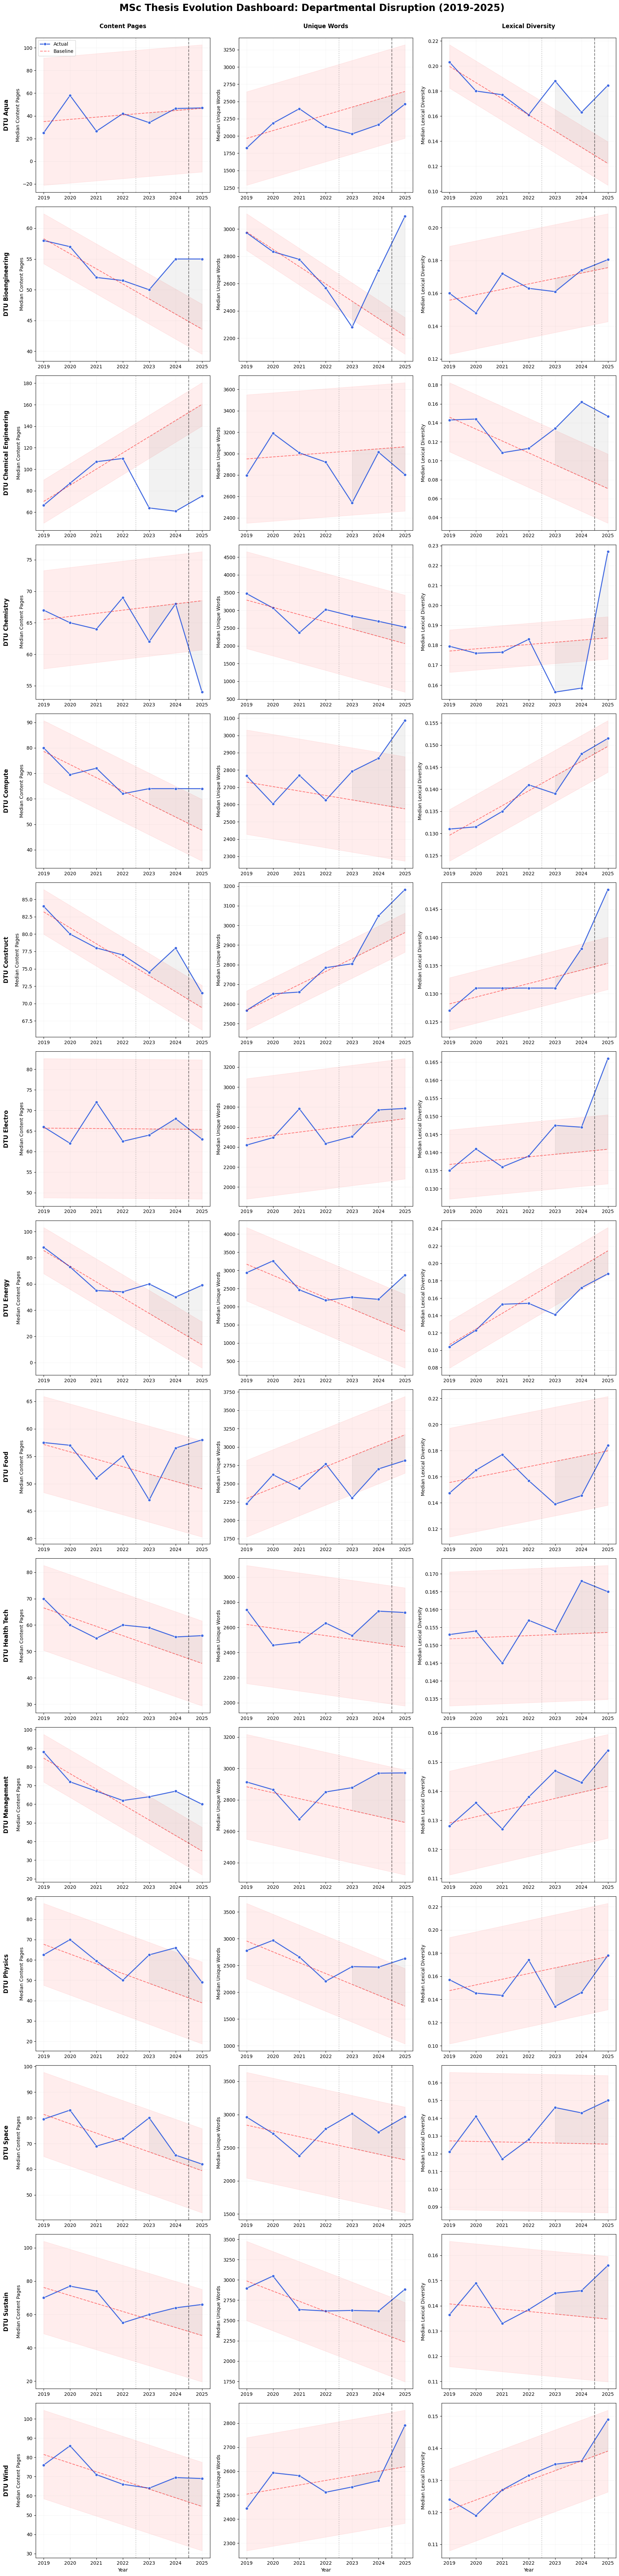

In [17]:
robust_list, df_robust = get_robust_departments(df_filtered_final, min_n=20)
plot_smoking_gun_grid_dep(df_robust, robust_list, version=2)